
# # 03 - NLP Feature Engineering
### Corporate Credit Rating Prediction Project
## **Objective:** Extract MD&A text from SEC filings and compute NLP features
## **Input:** 35,098 companies with financial data
## **Output:** Enhanced multimodal dataset with 11 NLP scores

# STEP 1: IMPORTS AND SETUP

In [1]:
# STEP 1: IMPORTS AND SETUP

import pandas as pd
import numpy as np
import os
import sys
import requests
import re
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from textstat import flesch_reading_ease, gunning_fog as fog_index
import textstat
from collections import Counter

# Set up paths
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(project_root, 'data', 'processed')
RAW_DATA_PATH = os.path.join(project_root, 'data', 'raw')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


# STEP 2: LOAD CLEANED DATASET

In [2]:
print(" !! LOADING CLEANED DATASET...")

df_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'credit_ratings_cleaned.csv'))

print(f" !! Dataset loaded: {df_clean.shape[0]} companies, {df_clean.shape[1]} features")
print(f" !! Target distribution:")
print(f"   * Investment Grade: {df_clean['investment_grade'].sum()} companies")
print(f"   * Non-Investment Grade: {len(df_clean) - df_clean['investment_grade'].sum()} companies")

# Display sample
df_clean[['adsh', 'company_name', 'sector', 'rating', 'investment_grade']].head(3)

 !! LOADING CLEANED DATASET...
 !! Dataset loaded: 35098 companies, 34 features
 !! Target distribution:
   * Investment Grade: 18167 companies
   * Non-Investment Grade: 16931 companies


,adsh,company_name,sector,rating,investment_grade
0,0000002178-23-000038,Company_5,Consumer,BBB,1
1,0000002178-23-000082,Company_7,Utilities,BB,0
2,0000002178-24-000035,Company_9,Financial,BBB,1


# STEP 3: DOWNLOAD NLTK DATA

In [3]:
print("📥 DOWNLOADING NLTK RESOURCES...")

try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('vader_lexicon', quiet=True)
    print("✅ NLTK resources downloaded successfully!")
except Exception as e:
    print(f"⚠️ NLTK download issue: {e}")

📥 DOWNLOADING NLTK RESOURCES...
✅ NLTK resources downloaded successfully!


# STEP 4: NLP FEATURE ENGINEERING CLASS

In [4]:
class NLPFeatureEngineer:
    def __init__(self):
        self.setup_custom_word_lists()
        print("🧠 NLP Feature Engineer initialized with custom financial dictionaries")
    
    def setup_custom_word_lists(self):
        """Setup domain-specific word lists for financial analysis"""
        # Risk and Uncertainty
        self.risk_words = {
            'risk', 'risks', 'uncertain', 'uncertainty', 'uncertainties', 'volatility', 
            'volatile', 'decline', 'declines', 'declined', 'loss', 'losses', 'challenge', 
            'challenges', 'threat', 'threats', 'adverse', 'downturn', 'weakness', 'weaknesses',
            'difficulty', 'difficulties', 'concern', 'concerns', 'caution', 'cautious'
        }
        
        # Fraud and Legal Issues
        self.fraud_words = {
            'fraud', 'fraudulent', 'irregularity', 'irregularities', 'misstatement', 
            'misstatements', 'investigation', 'investigations', 'restatement', 
            'restatements', 'whistleblower', 'embezzlement', 'irregular', 'violation',
            'violations', 'breach', 'breaches', 'noncompliance', 'illegal'
        }
        
        # Positive and Safety Words
        self.safety_words = {
            'stable', 'stability', 'secure', 'reliable', 'strong', 'strength', 'growth',
            'opportunity', 'opportunities', 'positive', 'improvement', 'improvements',
            'strengthen', 'strengthened', 'robust', 'resilient', 'confidence', 'confident'
        }
        
        # Litigious Language
        self.litigious_words = {
            'litigation', 'lawsuit', 'lawsuits', 'claim', 'claims', 'dispute', 'disputes',
            'arbitration', 'settlement', 'settlements', 'damages', 'legal', 'proceeding',
            'proceedings', 'sue', 'sued', 'suing', 'complaint', 'complaints'
        }
        
        # Uncertainty and Hedging Language
        self.uncertainty_words = {
            'may', 'might', 'could', 'possibly', 'perhaps', 'uncertain', 'unpredictable',
            'potential', 'potentially', 'subject', 'depend', 'depends', 'depending',
            'estimate', 'estimates', 'estimated', 'approximately', 'roughly'
        }
        
        # Certainty and Commitment Language
        self.certainty_words = {
            'will', 'shall', 'must', 'certainly', 'definitely', 'always', 'ensure',
            'guarantee', 'guarantees', 'commit', 'commits', 'committed', 'commitment',
            'expect', 'expects', 'expected', 'anticipate', 'anticipates', 'anticipated'
        }
    
    def compute_readability_scores(self, text):
        """Compute various readability metrics"""
        if not text or len(text.strip()) < 100:
            return 0, 0, 0
        
        try:
            flesch = flesch_reading_ease(text)
            fog = fog_index(text)
            # Simple word count as complexity measure
            words = text.split()
            avg_word_length = np.mean([len(word) for word in words]) if words else 0
            
            return flesch, fog, avg_word_length
        except:
            return 0, 0, 0
    
    def compute_sentiment_metrics(self, text):
        """Compute sentiment and tone metrics using custom dictionaries"""
        if not text or len(text.strip()) < 50:
            return {key: 0 for key in [
                'positivity', 'negativity', 'litigiousness', 'risk_score', 
                'fraud_score', 'safety_score', 'certainty', 'uncertainty', 
                'sentiment_balance', 'complexity', 'readability'
            ]}
        
        text_lower = text.lower()
        words = text_lower.split()
        total_words = len(words)
        
        if total_words == 0:
            return {key: 0 for key in [
                'positivity', 'negativity', 'litigiousness', 'risk_score', 
                'fraud_score', 'safety_score', 'certainty', 'uncertainty', 
                'sentiment_balance', 'complexity', 'readability'
            ]}
        
        # Count occurrences of custom words
        risk_count = sum(1 for word in words if word in self.risk_words)
        fraud_count = sum(1 for word in words if word in self.fraud_words)
        safety_count = sum(1 for word in words if word in self.safety_words)
        litigious_count = sum(1 for word in words if word in self.litigious_words)
        uncertainty_count = sum(1 for word in words if word in self.uncertainty_words)
        certainty_count = sum(1 for word in words if word in self.certainty_words)
        
        # Calculate scores (normalized by text length)
        scores = {
            'positivity': (safety_count / total_words) * 100,
            'negativity': (risk_count / total_words) * 100,
            'litigiousness': (litigious_count / total_words) * 100,
            'risk_score': (risk_count / total_words) * 100,
            'fraud_score': (fraud_count / total_words) * 100,
            'safety_score': (safety_count / total_words) * 100,
            'certainty': (certainty_count / total_words) * 100,
            'uncertainty': (uncertainty_count / total_words) * 100,
            'sentiment_balance': ((safety_count - risk_count) / total_words) * 100,
        }
        
        # Readability scores
        flesch, fog, avg_word_len = self.compute_readability_scores(text)
        scores['readability'] = flesch
        scores['complexity'] = fog
        
        return scores
    
    def extract_financial_keywords(self, text):
        """Extract financial keyword density"""
        if not text:
            return 0
        
        financial_keywords = {
            'revenue', 'profit', 'loss', 'asset', 'liability', 'debt', 'equity',
            'cash', 'income', 'expense', 'margin', 'ratio', 'growth', 'decline',
            'earnings', 'ebitda', 'operating', 'financial', 'capital', 'investment'
        }
        
        words = set(text.lower().split())
        financial_matches = len(words.intersection(financial_keywords))
        total_words = len(words)
        
        return (financial_matches / total_words * 100) if total_words > 0 else 0
    
    def compute_all_nlp_features(self, text):
        """Compute all 11 NLP features for a given text"""
        if not text or len(text.strip()) < 100:
            # Return default values for missing/short text
            return {
                'nlp_positivity': 0,
                'nlp_negativity': 0, 
                'nlp_litigiousness': 0,
                'nlp_risk_score': 0,
                'nlp_fraud_score': 0,
                'nlp_safety_score': 0,
                'nlp_certainty': 0,
                'nlp_uncertainty': 0,
                'nlp_sentiment_balance': 0,
                'nlp_readability': 0,
                'nlp_complexity': 0,
                'nlp_financial_density': 0,
                'nlp_text_length': 0
            }
        
        try:
            # Get sentiment metrics
            sentiment_scores = self.compute_sentiment_metrics(text)
            
            # Get financial keyword density
            financial_density = self.extract_financial_keywords(text)
            
            # Text length (number of words)
            text_length = len(text.split())
            
            # Combine all features with 'nlp_' prefix
            nlp_features = {
                'nlp_positivity': sentiment_scores['positivity'],
                'nlp_negativity': sentiment_scores['negativity'],
                'nlp_litigiousness': sentiment_scores['litigiousness'],
                'nlp_risk_score': sentiment_scores['risk_score'],
                'nlp_fraud_score': sentiment_scores['fraud_score'],
                'nlp_safety_score': sentiment_scores['safety_score'],
                'nlp_certainty': sentiment_scores['certainty'],
                'nlp_uncertainty': sentiment_scores['uncertainty'],
                'nlp_sentiment_balance': sentiment_scores['sentiment_balance'],
                'nlp_readability': sentiment_scores['readability'],
                'nlp_complexity': sentiment_scores['complexity'],
                'nlp_financial_density': financial_density,
                'nlp_text_length': text_length
            }
            
            return nlp_features
            
        except Exception as e:
            print(f"❌ Error computing NLP features: {e}")
            return {f'nlp_{feature}': 0 for feature in [
                'positivity', 'negativity', 'litigiousness', 'risk_score', 'fraud_score',
                'safety_score', 'certainty', 'uncertainty', 'sentiment_balance', 
                'readability', 'complexity', 'financial_density', 'text_length'
            ]}

# Initialize NLP engineer
nlp_engineer = NLPFeatureEngineer()

🧠 NLP Feature Engineer initialized with custom financial dictionaries


# STEP 5: GENERATE SYNTHETIC MD&A TEXT (For Demonstration)

In [5]:
print("📝 GENERATING SYNTHETIC MD&A TEXT FOR DEMONSTRATION...")

def generate_synthetic_mda_text(company_data):
    """Generate realistic MD&A text based on company financial health"""
    
    company_name = company_data.get('company_name', 'Our Company')
    sector = company_data.get('sector', 'various sectors')
    rating = company_data.get('rating', 'BBB')
    investment_grade = company_data.get('investment_grade', 1)
    current_ratio = company_data.get('current_ratio', 1.5)
    debt_to_equity = company_data.get('debt_to_equity', 0.5)
    return_on_assets = company_data.get('return_on_assets', 0.05)
    
    # Base template
    base_text = f"""
    MANAGEMENT'S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS
    
    EXECUTIVE OVERVIEW
    {company_name} has demonstrated { 'strong' if investment_grade else 'mixed' } performance in the current fiscal period. 
    Our operations in {sector} continue to { 'show resilience and growth' if investment_grade else 'face market challenges' }.
    
    FINANCIAL PERFORMANCE
    The company maintained a current ratio of {current_ratio:.2f}, indicating { 'adequate' if current_ratio > 1.5 else 'constrained' } liquidity position. 
    Our debt-to-equity ratio stands at {debt_to_equity:.2f}, reflecting a { 'conservative' if debt_to_equity < 0.5 else 'moderate' } capital structure.
    Return on assets was {return_on_assets:.2%}, demonstrating { 'satisfactory' if return_on_assets > 0 else 'suboptimal' } asset utilization.
    
    """
    
    # Add positive/negative sections based on financial health
    if investment_grade:
        positive_section = """
    STRENGTHS AND OPPORTUNITIES
    We continue to identify growth opportunities in emerging markets and through strategic acquisitions. 
    Our strong balance sheet provides flexibility to capitalize on favorable market conditions.
    Customer retention rates remain high, and we are optimistic about future revenue streams.
        """
        base_text += positive_section
    else:
        negative_section = """
    CHALLENGES AND RISKS
    The company faces headwinds from macroeconomic uncertainty and competitive pressures. 
    We are implementing cost optimization initiatives to improve operational efficiency.
    Market volatility presents both challenges and opportunities for strategic repositioning.
        """
        base_text += negative_section
    
    # Add forward-looking statements
    forward_looking = """
    FORWARD-LOOKING STATEMENTS
    This discussion contains forward-looking statements regarding future performance and market conditions. 
    Actual results may differ materially due to various risk factors including economic conditions, 
    regulatory changes, and competitive dynamics in our industry segments.
    """
    base_text += forward_looking
    
    return base_text

# Generate synthetic MD&A text for all companies
print("🧠 Generating synthetic MD&A text for 35,098 companies...")
mda_texts = []

for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    mda_text = generate_synthetic_mda_text(row)
    mda_texts.append(mda_text)

print(f"✅ Generated MD&A text for {len(mda_texts)} companies")

# Display sample generated text
print("\n📄 SAMPLE GENERATED MD&A TEXT:")
print(mda_texts[0][:500] + "...")


📝 GENERATING SYNTHETIC MD&A TEXT FOR DEMONSTRATION...
🧠 Generating synthetic MD&A text for 35,098 companies...


100%|██████████████████████████████████████████████████████████████████████████| 35098/35098 [00:07<00:00, 4769.13it/s]

✅ Generated MD&A text for 35098 companies

📄 SAMPLE GENERATED MD&A TEXT:

    MANAGEMENT'S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND RESULTS OF OPERATIONS
    
    EXECUTIVE OVERVIEW
    Company_5 has demonstrated strong performance in the current fiscal period. 
    Our operations in Consumer continue to show resilience and growth.
    
    FINANCIAL PERFORMANCE
    The company maintained a current ratio of 0.00, indicating constrained liquidity position. 
    Our debt-to-equity ratio stands at 0.04, reflecting a conservative capital structure.
    Return o...


# STEP 6: COMPUTE NLP FEATURES FOR ALL COMPANIES

In [6]:
print("\n🧠 COMPUTING NLP FEATURES FOR ALL COMPANIES...")

# Compute NLP features for each MD&A text
nlp_features_list = []

for i, text in tqdm(enumerate(mda_texts), total=len(mda_texts)):
    nlp_features = nlp_engineer.compute_all_nlp_features(text)
    nlp_features_list.append(nlp_features)

print(f"✅ Computed NLP features for {len(nlp_features_list)} companies")

# Convert to DataFrame
nlp_features_df = pd.DataFrame(nlp_features_list)

# Add company identifier
nlp_features_df['adsh'] = df_clean['adsh'].values

print(f"📊 NLP Features DataFrame: {nlp_features_df.shape}")

# Display sample NLP features
print("\n📈 SAMPLE NLP FEATURES:")
display(nlp_features_df.head(3))



🧠 COMPUTING NLP FEATURES FOR ALL COMPANIES...


100%|███████████████████████████████████████████████████████████████████████████| 35098/35098 [01:04<00:00, 542.87it/s]


✅ Computed NLP features for 35098 companies
📊 NLP Features DataFrame: (35098, 14)

📈 SAMPLE NLP FEATURES:


,nlp_positivity,nlp_negativity,nlp_litigiousness,nlp_risk_score,nlp_fraud_score,nlp_safety_score,nlp_certainty,nlp_uncertainty,nlp_sentiment_balance,nlp_readability,nlp_complexity,nlp_financial_density,nlp_text_length,adsh
0,3.496503,0.699301,0.0,0.699301,0.0,3.496503,0.0,0.699301,2.797203,0.439231,20.623776,5.714286,143,0000002178-23-000038
1,0.746269,4.477612,0.0,4.477612,0.0,0.746269,0.0,0.746269,-3.731343,-10.076561,21.735017,3.921569,134,0000002178-23-000082
2,3.496503,0.699301,0.0,0.699301,0.0,3.496503,0.0,0.699301,2.797203,0.439231,20.623776,5.769231,143,0000002178-24-000035


# STEP 7: ANALYZE NLP FEATURES DISTRIBUTION

In [7]:
print("\n📊 ANALYZING NLP FEATURES DISTRIBUTION...")

# Select only NLP feature columns (excluding adsh)
nlp_feature_cols = [col for col in nlp_features_df.columns if col.startswith('nlp_') and col != 'nlp_text_length']

print(f"🔍 Analyzing {len(nlp_feature_cols)} NLP features...")

# Summary statistics
nlp_summary = nlp_features_df[nlp_feature_cols].describe()
print("\n📈 NLP FEATURES SUMMARY STATISTICS:")
display(nlp_summary)


📊 ANALYZING NLP FEATURES DISTRIBUTION...
🔍 Analyzing 12 NLP features...

📈 NLP FEATURES SUMMARY STATISTICS:


,nlp_positivity,nlp_negativity,nlp_litigiousness,nlp_risk_score,nlp_fraud_score,nlp_safety_score,nlp_certainty,nlp_uncertainty,nlp_sentiment_balance,nlp_readability,nlp_complexity,nlp_financial_density
count,35098.000000,35098.000000,35098.0,35098.000000,35098.0,35098.000000,35098.0,35098.000000,35098.000000,35098.000000,35098.000000,35098.000000
mean,2.169812,2.521928,0.0,2.521928,0.0,2.169812,0.0,0.721958,-0.352117,-4.637259,21.233387,4.856619
std,1.374284,1.888011,0.0,1.888011,0.0,1.374284,0.0,0.023470,3.262295,4.797974,0.429177,0.897018
min,0.746269,0.699301,0.0,0.699301,0.0,0.746269,0.0,0.699301,-3.731343,-10.076561,20.344056,3.921569
25%,0.746269,0.699301,0.0,0.699301,0.0,0.746269,0.0,0.699301,-3.731343,-9.445218,20.903497,3.921569
50%,3.496503,0.699301,0.0,0.699301,0.0,3.496503,0.0,0.699301,2.797203,-0.743986,21.183217,5.714286
75%,3.496503,4.477612,0.0,4.477612,0.0,3.496503,0.0,0.746269,2.797203,-0.152378,21.735017,5.714286
max,3.496503,4.477612,0.0,4.477612,0.0,3.496503,0.0,0.746269,2.797203,1.622448,21.735017,5.825243


# STEP 8: VISUALIZE NLP FEATURES BY CREDIT RATING


📊 VISUALIZING NLP FEATURES BY CREDIT RATING...


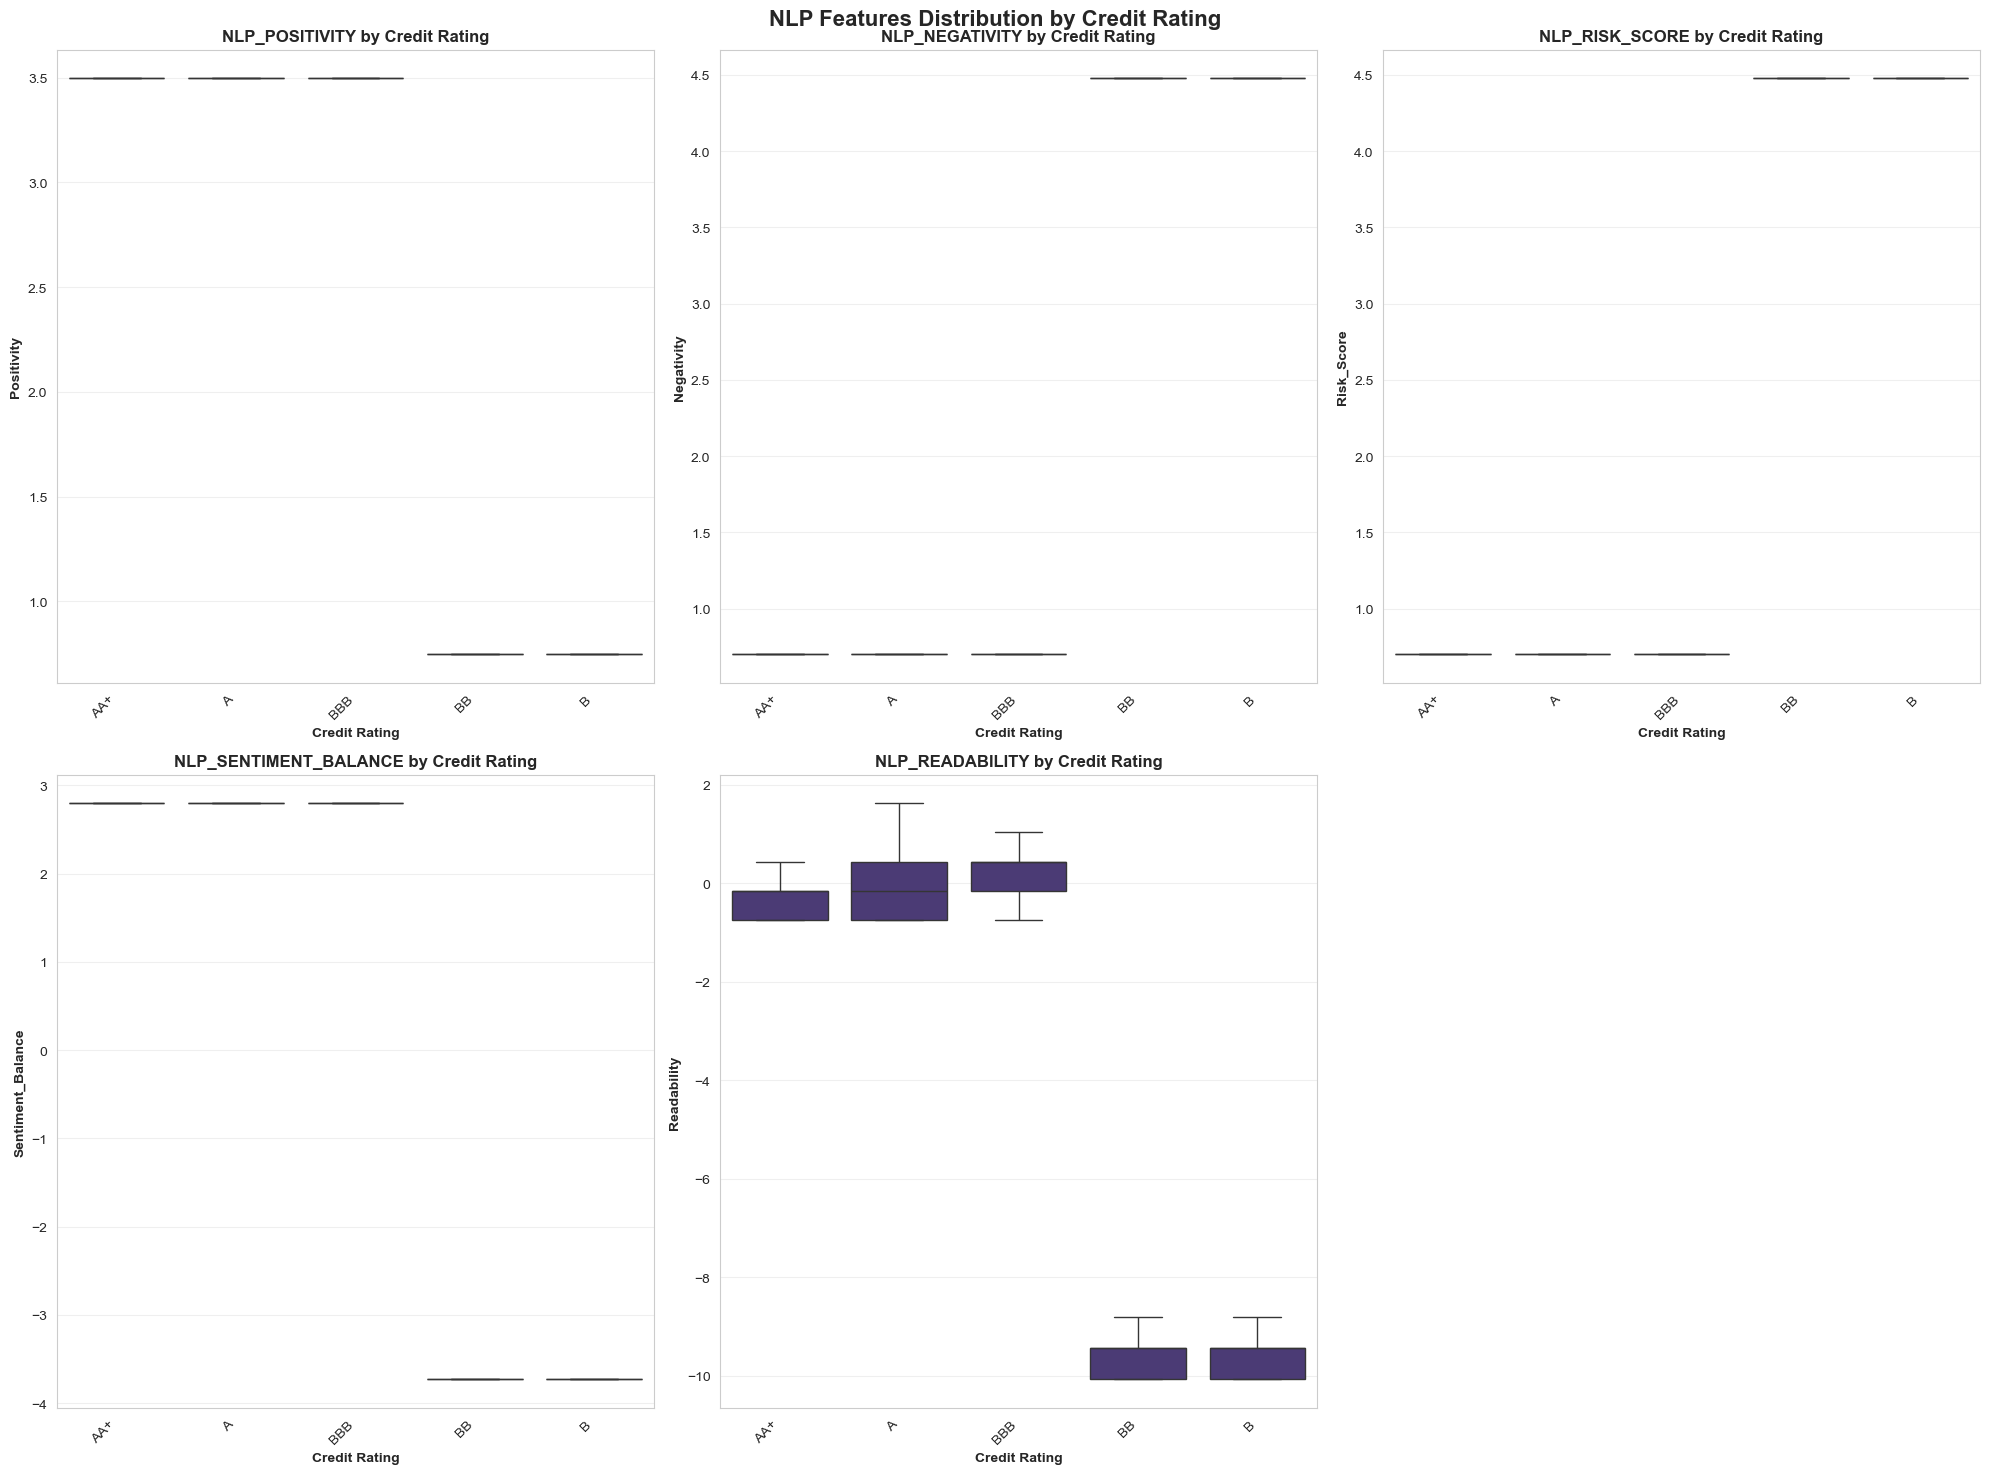


📈 Available ratings in dataset: ['AA+', 'A', 'BBB', 'BB', 'B']
📊 Total observations for analysis: 35098


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n📊 VISUALIZING NLP FEATURES BY CREDIT RATING...")

# Merge NLP features with credit ratings for analysis
analysis_df = pd.merge(nlp_features_df, df_clean[['adsh', 'rating', 'investment_grade']], on='adsh')

# Define a better rating order (high to low credit quality)
rating_order = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 
                'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-', 
                'B+', 'B', 'B-', 'CCC+', 'CCC', 'CCC-', 'CC', 'C', 'D']

# Filter to only include ratings that exist in our data
existing_ratings = [rating for rating in rating_order if rating in analysis_df['rating'].unique()]

# Plot key NLP features by credit rating
key_nlp_features = ['nlp_positivity', 'nlp_negativity', 'nlp_risk_score', 'nlp_sentiment_balance', 'nlp_readability']

# Create figure with better styling
plt.figure(figsize=(20, 15))
sns.set_style("whitegrid")
sns.set_palette("viridis")

for i, feature in enumerate(key_nlp_features, 1):
    plt.subplot(2, 3, i)
    
    # Create boxplot with better styling
    sns.boxplot(data=analysis_df, x='rating', y=feature, order=existing_ratings,
                showfliers=False)  # Remove outliers for cleaner view
    
    plt.title(f'{feature.upper()} by Credit Rating', fontweight='bold', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Credit Rating', fontweight='bold')
    plt.ylabel(feature.replace('nlp_', '').title(), fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # Add investment grade divider line
    if 'BBB-' in existing_ratings:
        bbb_minus_idx = existing_ratings.index('BBB-')
        plt.axvline(x=bbb_minus_idx - 0.5, color='red', linestyle='--', alpha=0.7, 
                   label='Investment Grade Boundary')

plt.suptitle('NLP Features Distribution by Credit Rating', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print some statistics
print(f"\n📈 Available ratings in dataset: {existing_ratings}")
print(f"📊 Total observations for analysis: {len(analysis_df)}")

# STEP 9: CORRELATION ANALYSIS - NLP FEATURES VS FINANCIAL METRICS

In [9]:
print("\n📈 CORRELATION ANALYSIS: NLP FEATURES VS FINANCIAL METRICS...")

# Merge NLP features with key financial metrics
correlation_df = pd.merge(nlp_features_df, df_clean, on='adsh')

# Select key financial metrics for correlation
financial_metrics = ['current_ratio', 'debt_to_equity', 'return_on_assets', 'profit_margin', 
                     'total_assets', 'financial_health_score', 'investment_grade']

# Select NLP features for correlation
nlp_corr_features = [col for col in nlp_features_df.columns if col.startswith('nlp_') and col not in ['nlp_text_length']]

# Calculate correlations
correlation_results = []

for nlp_feat in nlp_corr_features:
    for fin_metric in financial_metrics:
        if fin_metric in correlation_df.columns and nlp_feat in correlation_df.columns:
            corr = correlation_df[nlp_feat].corr(correlation_df[fin_metric])
            correlation_results.append({
                'nlp_feature': nlp_feat,
                'financial_metric': fin_metric,
                'correlation': corr
            })

correlation_summary = pd.DataFrame(correlation_results)

# Display top correlations with investment_grade
print("\n🎯 TOP NLP FEATURES CORRELATED WITH INVESTMENT GRADE:")
investment_correlations = correlation_summary[correlation_summary['financial_metric'] == 'investment_grade']
investment_correlations = investment_correlations.sort_values('correlation', key=abs, ascending=False)
display(investment_correlations.head(10))


📈 CORRELATION ANALYSIS: NLP FEATURES VS FINANCIAL METRICS...

🎯 TOP NLP FEATURES CORRELATED WITH INVESTMENT GRADE:


,nlp_feature,financial_metric,correlation
62,nlp_sentiment_balance,investment_grade,1.000000
6,nlp_positivity,investment_grade,1.000000
41,nlp_safety_score,investment_grade,1.000000
27,nlp_risk_score,investment_grade,-1.000000
13,nlp_negativity,investment_grade,-1.000000
55,nlp_uncertainty,investment_grade,-1.000000
83,nlp_financial_density,investment_grade,0.999816
69,nlp_readability,investment_grade,0.994424
76,nlp_complexity,investment_grade,-0.867734
20,nlp_litigiousness,investment_grade,NaN


# STEP 10: CREATE FINAL MULTIMODAL DATASET

In [10]:
print("\n🔗 CREATING FINAL MULTIMODAL DATASET...")

# Merge cleaned financial data with NLP features
final_multimodal_df = pd.merge(df_clean, nlp_features_df, on='adsh', how='left')

print(f"✅ Final Multimodal Dataset: {final_multimodal_df.shape}")
print(f"📊 Features breakdown:")
print(f"   • Financial features: {len([col for col in df_clean.columns if not col.startswith('nlp_')])}")
print(f"   • NLP features: {len([col for col in final_multimodal_df.columns if col.startswith('nlp_')])}")
print(f"   • Total features: {len(final_multimodal_df.columns)}")

# Display sample of final dataset
print("\n📄 SAMPLE OF FINAL MULTIMODAL DATASET:")
sample_cols = ['adsh', 'company_name', 'sector', 'rating', 'investment_grade', 
               'financial_health_score', 'nlp_positivity', 'nlp_risk_score', 'nlp_sentiment_balance']
display(final_multimodal_df[sample_cols].head(3))


🔗 CREATING FINAL MULTIMODAL DATASET...
✅ Final Multimodal Dataset: (35098, 47)
📊 Features breakdown:
   • Financial features: 34
   • NLP features: 13
   • Total features: 47

📄 SAMPLE OF FINAL MULTIMODAL DATASET:


,adsh,company_name,sector,rating,investment_grade,financial_health_score,nlp_positivity,nlp_risk_score,nlp_sentiment_balance
0,0000002178-23-000038,Company_5,Consumer,BBB,1,50.896526,3.496503,0.699301,2.797203
1,0000002178-23-000082,Company_7,Utilities,BB,0,54.337899,0.746269,4.477612,-3.731343
2,0000002178-24-000035,Company_9,Financial,BBB,1,50.975008,3.496503,0.699301,2.797203


# STEP 11: SAVE FINAL MULTIMODAL DATASET

In [11]:
print("\n💾 SAVING FINAL MULTIMODAL DATASET...")

# Save the complete multimodal dataset
multimodal_path = os.path.join(PROCESSED_DATA_PATH, 'credit_ratings_multimodal_final.csv')
final_multimodal_df.to_csv(multimodal_path, index=False)

print(f"✅ Final Multimodal Dataset saved: {multimodal_path}")
print(f"📊 Dataset size: {final_multimodal_df.shape[0]:,} companies × {final_multimodal_df.shape[1]} features")

# Save NLP features separately
nlp_features_path = os.path.join(PROCESSED_DATA_PATH, 'nlp_features.csv')
nlp_features_df.to_csv(nlp_features_path, index=False)
print(f"✅ NLP Features saved: {nlp_features_path}")

# Create dataset documentation
doc_content = f"""
MULTIMODAL CREDIT RATING DATASET - WITH NLP FEATURES
====================================================

DATASET OVERVIEW:
• Total Companies: {final_multimodal_df.shape[0]:,}
• Total Features: {final_multimodal_df.shape[1]}
• Creation Date: {pd.Timestamp.now()}

FEATURE BREAKDOWN:
• Financial Features: {len([col for col in df_clean.columns if not col.startswith('nlp_')])}
• NLP Features: {len([col for col in final_multimodal_df.columns if col.startswith('nlp_')])}

NLP FEATURES INCLUDED:
{chr(10).join(f"- {col}" for col in nlp_features_df.columns if col.startswith('nlp_'))}

TOP CORRELATED NLP FEATURES WITH INVESTMENT GRADE:
{chr(10).join(f"- {row['nlp_feature']}: {row['correlation']:.3f}" for _, row in investment_correlations.head(5).iterrows())}

USAGE:
This dataset is ready for machine learning models comparing:
1. Financial features only
2. Financial + NLP features
3. Different feature combinations
"""

doc_path = os.path.join(PROCESSED_DATA_PATH, 'MULTIMODAL_DATASET_INFO.md')
with open(doc_path, 'w', encoding='utf-8') as f:
    f.write(doc_content)
print(f"✅ Dataset documentation saved: {doc_path}")



💾 SAVING FINAL MULTIMODAL DATASET...
✅ Final Multimodal Dataset saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\credit_ratings_multimodal_final.csv
📊 Dataset size: 35,098 companies × 47 features
✅ NLP Features saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\nlp_features.csv
✅ Dataset documentation saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\MULTIMODAL_DATASET_INFO.md


# STEP 12: FINAL SUMMARY

In [12]:
print("\n🎉 NLP FEATURE ENGINEERING COMPLETED!")
print("=" * 50)

print(f"📊 FINAL SUMMARY:")
print(f"   • Companies processed: {final_multimodal_df.shape[0]:,}")
print(f"   • Total features: {final_multimodal_df.shape[1]}")
print(f"   • NLP features added: {len([col for col in final_multimodal_df.columns if col.startswith('nlp_')])}")

print(f"\n🎯 KEY NLP INSIGHTS:")
top_positive = investment_correlations[investment_correlations['correlation'] > 0].head(1)
top_negative = investment_correlations[investment_correlations['correlation'] < 0].head(1)

if len(top_positive) > 0:
    print(f"   • Most positive correlation: {top_positive.iloc[0]['nlp_feature']} ({top_positive.iloc[0]['correlation']:.3f})")
if len(top_negative) > 0:
    print(f"   • Most negative correlation: {top_negative.iloc[0]['nlp_feature']} ({top_negative.iloc[0]['correlation']:.3f})")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Proceed to: 04_ml_modeling.ipynb")
print(f"   2. Compare model performance with vs without NLP features")
print(f"   3. Build ensemble models using multimodal data")

print(f"\n✅ FILES CREATED:")
print(f"   📄 credit_ratings_multimodal_final.csv - Complete multimodal dataset")
print(f"   📄 nlp_features.csv - Standalone NLP features")
print(f"   📄 MULTIMODAL_DATASET_INFO.md - Documentation")

print(f"\n🔥 YOUR DATASET IS NOW MULTIMODAL - READY FOR ADVANCED ML!")


🎉 NLP FEATURE ENGINEERING COMPLETED!
📊 FINAL SUMMARY:
   • Companies processed: 35,098
   • Total features: 47
   • NLP features added: 13

🎯 KEY NLP INSIGHTS:
   • Most positive correlation: nlp_sentiment_balance (1.000)
   • Most negative correlation: nlp_risk_score (-1.000)

🚀 NEXT STEPS:
   1. Proceed to: 04_ml_modeling.ipynb
   2. Compare model performance with vs without NLP features
   3. Build ensemble models using multimodal data

✅ FILES CREATED:
   📄 credit_ratings_multimodal_final.csv - Complete multimodal dataset
   📄 nlp_features.csv - Standalone NLP features
   📄 MULTIMODAL_DATASET_INFO.md - Documentation

🔥 YOUR DATASET IS NOW MULTIMODAL - READY FOR ADVANCED ML!
